In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Module Download

In [ ]:
!pip install vnstock

# Import Packages

In [ ]:
from vnstock import *

import numpy as np
import pandas as pd
from datetime import datetime

from sklearn.impute import KNNImputer

# Input Data

## Tickers List:

In [ ]:
from vnstock import Reference

# 1. Initialize the Reference layer and fetch data
ref = Reference()
df = ref.equity.list_by_exchange()

hose_df = df[(df["exchange"] == "HOSE") & (df["type"] == "stock")]
hose_tickers = hose_df.symbol.tolist()

print(hose_tickers)

['DBT', 'DSN', 'VPG', 'HPG', 'VGC', 'HT1', 'TVT', 'DGW', 'HHS', 'VTO', 'IMP', 'FPT', 'STK', 'TCD', 'BCM', 'TNH', 'ST8', 'VSI', 'CTD', 'CRV', 'ADS', 'LM8', 'GTA', 'HPX', 'PTB', 'GEX', 'SVT', 'NT2', 'VSC', 'SVD', 'HPA', 'HTN', 'CII', 'BTP', 'CTF', 'DAT', 'CRE', 'NTL', 'DSC', 'PLP', 'TCX', 'VPI', 'GMH', 'L10', 'VRC', 'SFG', 'KLB', 'VRE', 'HTG', 'CLW', 'TTA', 'DIG', 'NSC', 'SJD', 'VPD', 'TNT', 'CCI', 'ANT', 'UIC', 'VPS', 'AAM', 'DGC', 'AAT', 'HAX', 'PMG', 'VDS', 'VJC', 'CIG', 'STB', 'APH', 'FCN', 'ACL', 'PNJ', 'NAB', 'NHT', 'PDV', 'NNC', 'SC5', 'SGN', 'VFG', 'DXV', 'GEL', 'SVC', 'TEG', 'RYG', 'PPC', 'PVP', 'VDP', 'LHG', 'AGG', 'HAR', 'OGC', 'ACB', 'NKG', 'ICT', 'APG', 'SBV', 'GMD', 'HDB', 'PTL', 'VIP', 'BVH', 'SKG', 'VID', 'DTT', 'TCH', 'TAL', 'PVT', 'D2D', 'SJS', 'DPR', 'AGR', 'HII', 'DPM', 'ASP', 'SHI', 'TMP', 'DC4', 'TDP', 'SFC', 'GEE', 'VHC', 'DLG', 'ADG', 'DCM', 'NLG', 'SFI', 'PLX', 'HDG', 'PET', 'AST', 'TDH', 'TYA', 'HTI', 'HVH', 'PDN', 'TLH', 'KDH', 'LGL', 'PTC', 'DHC', 'PNC', 'DQC'

# LSTM process

## Phase 1: Data Engineering and Input Formatting

In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler

TIME_STEPS = 20
master_X = []
master_metadata = []  # To track which ticker and date each sequence belongs to

# --- STEP 1a: First pass to find common columns across all stocks ---
print("Aligning feature columns across all datasets...")
common_columns = None

for ticker in hose_tickers:
    df_temp = pd.read_csv(f"/content/drive/MyDrive/Colab Notebooks/Fundamental Analysis AI level/Technical Analysis Data/{ticker}_ta_board.csv", nrows=5).set_index("time")

    # Process column names to match what they will look like after transformation
    price_columns = ['open', 'high', 'low', 'close']
    current_cols = set(df_temp.columns)

    # Simulate removing raw prices and adding log returns to anticipate final shape
    for col in price_columns:
        if col in current_cols:
            current_cols.remove(col)
            current_cols.add(f'{col}_log_ret')

    if common_columns is None:
        common_columns = current_cols
    else:
        common_columns = common_columns.intersection(current_cols)

# Convert to a sorted list to guarantee strict, identical column ordering
common_columns = sorted(list(common_columns))
print(f"Found {len(common_columns)} universally matching features across all stocks.\n")


# --- STEP 1b: Second pass to build the master 3D tensor ---
for ticker in hose_tickers:

    df = pd.read_csv(f"/content/drive/MyDrive/Colab Notebooks/Fundamental Analysis AI level/Technical Analysis Data/{ticker}_ta_board.csv").set_index("time")

    # Skip if the file doesn't have enough rows to form even a single sequence
    if len(df) < TIME_STEPS + 1:
        print(f"Skipping {ticker}: Not enough data rows.")
        continue

    # 1. Stationarity
    price_columns = ['open', 'high', 'low', 'close']
    for col in price_columns:
        df[f'{col}_log_ret'] = np.log(df[col] / df[col].shift(1))

    df = df.drop(columns=price_columns).dropna()

    # CRITICAL FIX: Keep only the universal intersecting columns in exact order
    # This guarantees dimension 2 will match perfectly for every single stock
    df = df[common_columns]

    # Keep track of valid timestamps for this specific stock
    valid_dates = df.index

    # 2. Scaling
    scaler = StandardScaler()
    scaled_features = scaler.fit_transform(df)

    # 3. Sequence Generation
    sequences = []
    for i in range(len(scaled_features) - TIME_STEPS + 1):
        sequences.append(scaled_features[i : (i + TIME_STEPS)])

        # Track the ticker and the *last date* of the 20-day window
        master_metadata.append({'Ticker': ticker, 'Date': valid_dates[i + TIME_STEPS - 1]})

    master_X.append(np.array(sequences))

# Combine all individual stock tensors into one massive 3D tensor
X_combined = np.concatenate(master_X, axis=0)

print(f"\nCombined 3D Tensor Shape successfully created: {X_combined.shape}")
# Dimension 2 will now match completely across all inputs!

Aligning feature columns across all datasets...
Found 91 universally matching features across all stocks.


Combined 3D Tensor Shape successfully created: (279747, 20, 91)


## Phase 2: The Deep Learning Feature Extractor

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

# --- 1. Hardware Configuration ---
# This explicitly tells PyTorch to use the GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training on device: {device}")

# --- 2. Memory-Efficient Data Loading ---
# Convert your massive NumPy array to a PyTorch Tensor
X_tensor = torch.tensor(X_combined, dtype=torch.float32)

# Create a dataset and a DataLoader to feed data in batches
# This prevents RAM/VRAM overflow
batch_size = 256
dataset = TensorDataset(X_tensor, X_tensor) # Input and Target are the same (X)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

# --- 3. The PyTorch Model Architecture ---
class PyTorchLSTMAutoencoder(nn.Module):
    def __init__(self, n_features, latent_dim, time_steps):
        super(PyTorchLSTMAutoencoder, self).__init__()
        self.latent_dim = latent_dim
        self.time_steps = time_steps

        # Encoder
        self.encoder_lstm = nn.LSTM(n_features, latent_dim, batch_first=True)

        # Decoder
        self.decoder_lstm = nn.LSTM(latent_dim, latent_dim, batch_first=True)
        self.decoder_dense = nn.Linear(latent_dim, n_features)

    def encode(self, x):
        # Pass sequence through Encoder
        _, (h_n, _) = self.encoder_lstm(x)
        # h_n contains the final hidden state. Squeeze it to shape: (batch, latent_dim)
        return h_n.squeeze(0)

    def forward(self, x):
        # 1. Compress to Latent Space (Z)
        z = self.encode(x)

        # 2. Repeat Vector (Mimicking Keras 'RepeatVector')
        # Expand Z from (batch, latent_dim) to (batch, time_steps, latent_dim)
        z_repeated = z.unsqueeze(1).repeat(1, self.time_steps, 1)

        # 3. Reconstruct
        decoded_seq, _ = self.decoder_lstm(z_repeated)
        out = self.decoder_dense(decoded_seq)
        return out

# --- 4. Initialization ---
n_features = X_combined.shape[2]
latent_dim = 16
time_steps = TIME_STEPS

model = PyTorchLSTMAutoencoder(n_features, latent_dim, time_steps).to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# --- 5. The Training Loop ---
epochs = 50

print("Starting training...")
for epoch in range(epochs):
    model.train()
    running_loss = 0.0

    for batch_x, batch_y in dataloader:
        # PUSH DATA DIRECTLY TO GPU
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)

        # Forward pass
        optimizer.zero_grad()
        outputs = model(batch_x)
        loss = criterion(outputs, batch_y)

        # Backward pass and optimize
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * batch_x.size(0)

    epoch_loss = running_loss / len(dataloader.dataset)

    # Print progress every 5 epochs
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {epoch_loss:.6f}")

Training on device: cuda
Starting training...
Epoch [1/50], Loss: 0.475407
Epoch [5/50], Loss: 0.287130
Epoch [10/50], Loss: 0.276942
Epoch [15/50], Loss: 0.273446
Epoch [20/50], Loss: 0.270553
Epoch [25/50], Loss: 0.268180
Epoch [30/50], Loss: 0.265877

📋 Kết nối tài khoản Google Drive để lưu các thiết lập của dự án.
Dữ liệu phiên làm việc với Colab của bạn sẽ bị xóa nếu không lưu trữ vào Google Drive.

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Epoch [35/50], Loss: 0.264012
Epoch [40/50], Loss: 0.262717
Epoch [45/50], Loss: 0.261723
Epoch [50/50], Loss: 0.260874


## Phase 3: The Traditional Clustering Layer

In [ ]:
# --- Universal Extraction ---
model.eval() # Set model to evaluation mode
latent_vectors = []

# Use a DataLoader without shuffling to keep the original temporal order intact
extract_loader = DataLoader(dataset, batch_size=512, shuffle=False)

print("Extracting latent space Z...")
with torch.no_grad(): # Disable gradient calculation for faster inference
    for batch_x, _ in extract_loader:
        batch_x = batch_x.to(device)

        # Extract Z using our custom encode function
        z = model.encode(batch_x)

        # Move the results off the GPU back to the System RAM (CPU) as NumPy arrays
        latent_vectors.append(z.cpu().numpy())

# Combine batches into the final Z matrix
Z_combined = np.concatenate(latent_vectors, axis=0)
print(f"Latent Space Shape: {Z_combined.shape}")

# --- Clustering (Identical to before) ---
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=5, random_state=42)
labels = kmeans.fit_predict(Z_combined)

results_df = pd.DataFrame(master_metadata)
results_df['Cluster_Regime'] = labels

display(results_df.head(10))

Extracting latent space Z...
Latent Space Shape: (279747, 16)


,Ticker,Date,Cluster_Regime
0,DBT,2022-02-08 07:00:00,3
1,DBT,2022-02-09 07:00:00,3
2,DBT,2022-02-10 07:00:00,3
3,DBT,2022-02-11 07:00:00,3
4,DBT,2022-02-14 07:00:00,2
5,DBT,2022-02-15 07:00:00,2
6,DBT,2022-02-16 07:00:00,2
7,DBT,2022-02-17 07:00:00,2
8,DBT,2022-02-18 07:00:00,2
9,DBT,2022-02-21 07:00:00,2


## saving

In [ ]:
results_df.to_csv('/content/drive/MyDrive/Colab Notebooks/Fundamental Analysis AI level/results_df.csv', index=False)

# Plots

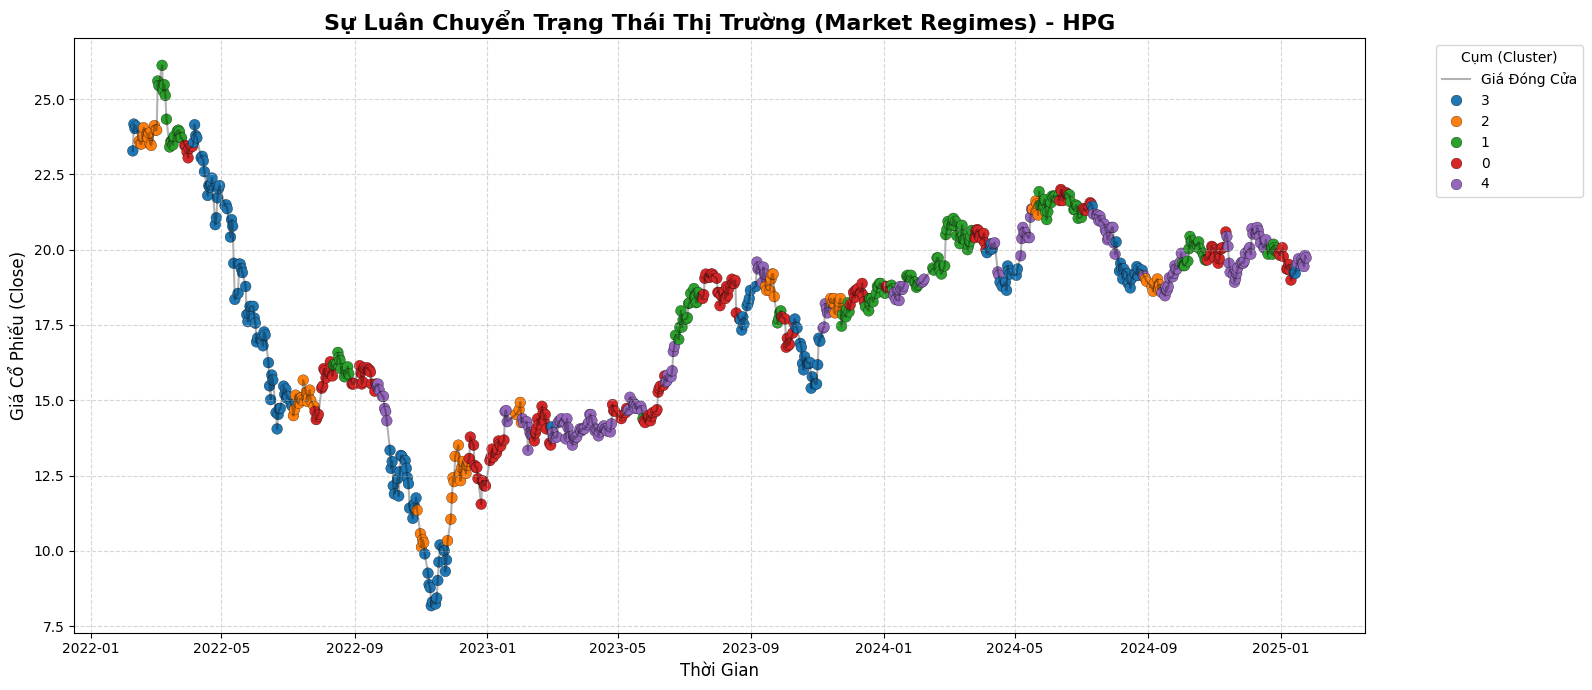

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Chọn một mã cổ phiếu bạn muốn phân tích
def ticker_plot(ticker_to_plot):
    # 2. Lọc dữ liệu Cluster của mã này từ kết quả ở Bước 3
    df_plot = results_df[results_df['Ticker'] == ticker_to_plot].copy()

    # Đảm bảo cột Date là định dạng datetime
    df_plot['Date'] = pd.to_datetime(df_plot['Date'])

    # 3. Lấy lại giá Close nguyên bản từ file CSV để làm trục Y
    # (Vì dữ liệu train đã bị scale và chuyển sang log return, ta cần giá gốc để dễ nhìn)
    original_df = pd.read_csv(f"/content/drive/MyDrive/Colab Notebooks/Fundamental Analysis AI level/Technical Analysis Data/{ticker_to_plot}_ta_board.csv")
    original_df['time'] = pd.to_datetime(original_df['time'])

    # Kết hợp (Merge) label của mô hình với giá Close gốc dựa trên thời gian
    merged_df = pd.merge(df_plot, original_df[['time', 'close']], left_on='Date', right_on='time', how='inner')

    # Ép kiểu Cluster_Regime sang chuỗi (string/category) để seaborn chia màu rời rạc, không bị dải màu gradient
    merged_df['Cluster_Regime'] = merged_df['Cluster_Regime'].astype(str)

    # --- 4. TIẾN HÀNH PLOT ---
    plt.figure(figsize=(16, 7))

    # Vẽ đường giá Close (mờ một chút để làm nền)
    plt.plot(merged_df['Date'], merged_df['close'], color='black', alpha=0.3, linewidth=1.5, label='Giá Đóng Cửa')

    # Vẽ các điểm Cluster đè lên đường giá
    sns.scatterplot(
        data=merged_df,
        x='Date',
        y='close',
        hue='Cluster_Regime',
        palette='tab10', # Bảng 10 màu phân biệt rõ ràng
        s=60,            # Kích thước chấm
        edgecolor='black',
        linewidth=0.2
    )

    # Tinh chỉnh giao diện biểu đồ
    plt.title(f'Sự Luân Chuyển Trạng Thái Thị Trường (Market Regimes) - {ticker_to_plot}', fontsize=16, fontweight='bold')
    plt.xlabel('Thời Gian', fontsize=12)
    plt.ylabel('Giá Cổ Phiếu (Close)', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend(title='Cụm (Cluster)', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()

    # Hiển thị
    plt.show()

ticker_plot(ticker_to_plot="HPG")
ticker_plot(ticker_to_plot="SSI")